In [1]:
from utils import * 

%load_ext autoreload 
%autoreload 2
# https://pmc.ncbi.nlm.nih.gov/articles/PMC9710616/
# print(f'Discarding {(genes_df.seq.apply(len) < MIN_LENGTH).sum()} proteins with length < {MIN_LENGTH} aa.') # Because structures can become untrustworthy.
# genes_df = genes_df[genes_df.seq.apply(len) >= MIN_LENGTH].copy()

# Structures

In [2]:
genes_df = pd.read_csv('../data/genes/genes.csv', index_col=0)
genes_df['cluster_id'] = genes_df.index.map(json.load(open('../data/genes/clusters.json', 'r')))
genes_df = genes_df[genes_df.genome_id != 'bz_12'].copy()

In [ ]:
foldseek_search_target_paths = dict()
foldseek_search_target_paths['pdb'] = '/shared/db/foldseek/latest/db/pdb'
foldseek_search_target_paths['bfvd'] = '/shared/db/foldseek/latest/db/bfvd'
foldseek_search_target_paths['alphafold_uniprot'] = '/shared/db/foldseek/latest/db/alphafold_uniprot'
foldseek_search_target_paths['alphafold_swissprot'] = '/shared/db/foldseek/latest/db/alphafold_swissprot'

foldseek_search_fields = 'query,target,evalue,gapopen,pident,fident,nident,qstart,qend,qlen,tstart,tend,tlen,alnlen,bits,cigar,qseq,tseq,qheader,theader,qaln,taln,mismatch,qcov,tcov,lddt,lddtfull,qtmscore,ttmscore,alntmscore,rmsd,prob'


## ColabFold structures

As a first pass, we used ColabFold to predict structures for all OrfM-predicted ORFs with valid start codons, including those which were not also supported by a Prodigal prediction. Unlike AlphaFold, which uses a time-intensive JackHMMer search to construct MSAs, ColabFold used MMseqs. Though this sacrifices accuracy somewhat, it dramatically reduces runtime. 

In [13]:
colabfold_output_dir = '../data/genes/colabfold/'

In [24]:
# First want to evaluate the quality of the ColabFold structures. 
paths = list(glob.glob(os.path.join(colabfold_output_dir, '*', '*.done.txt')))
paths = [path.replace('.done.txt', '') for path in paths]
print('Number of genes with ColabFold predictions:', len(paths))

colabfold_metadata_df = get_fold_metadata(paths, output_path='0-structures-colabfold_metadata.csv', parser=ColabFoldOutput)
colabfold_metadata_df = colabfold_metadata_df.set_index('name')
colabfold_metadata_df['msa_num_seqs'] -= 2 # Adjust because the query is included twice.


Number of genes with ColabFold predictions: 1639


### Foldseek search

In [14]:
min_length = 30 
prodigal_only = False

foldseek_search_query_name = 'genes'
foldseek_search_query_dir = f'../data/genes/foldseek/query/{foldseek_search_query_name}'
os.makedirs(foldseek_search_query_dir, exist_ok=True)

filter_ = genes_df.seq.apply(len) >= min_length
filter_ = filter_ & (~genes_df.prodigal_gene_id.isnull()) if prodigal_only else filter_ 

gene_ids = genes_df[filter_].index.values 
print('Number of Foldseek query sequences:', len(gene_ids))

Number of Foldseek query sequences: 1120


In [15]:
paths = [os.path.join(colabfold_output_dir, get_genome_id(gene_id), f'{gene_id}') for gene_id in gene_ids]

for path in tqdm(paths, desc=f'Copying structures to the query directory {foldseek_search_query_dir}.'):
    output = ColabFoldOutput(path)
    src_path = output.best_model_path
    dst_path = os.path.join(foldseek_search_query_dir, f'{get_gene_id(src_path)}.pdb')
    if not os.path.exists(dst_path):
        subprocess.run(f'cp {src_path} {dst_path}', shell=True, check=True)

Copying structures to the query directory ../data/genes/foldseek/query/genes.:   0%|          | 0/1120 [00:00<?, ?it/s]

Copying structures to the query directory ../data/genes/foldseek/query/genes.: 100%|██████████| 1120/1120 [00:06<00:00, 182.02it/s]


In [17]:
# Re-define the query path for the biotite server.
foldseek_search_query_dir = '/home/philippar/foldseek/query/genes/'

for target_name, target_path in foldseek_search_target_paths.items():
    foldseek_search_output_path = f'/home/philippar/foldseek/genes-{target_name}.tsv' # For running on biotite.
    cmd = f'foldseek easy-search {foldseek_search_query_dir} {target_path} {foldseek_search_output_path} tmp -a --alignment-type 1 --format-output "{foldseek_search_fields}"'
    print(f'sbatch --wrap "{cmd}"')

sbatch --wrap "foldseek easy-search /home/philippar/foldseek/query/genes/ /shared/db/foldseek/latest/db/pdb /home/philippar/foldseek/genes-pdb.tsv tmp -a --alignment-type 1 --format-output "query,target,evalue,gapopen,pident,fident,nident,qstart,qend,qlen,tstart,tend,tlen,alnlen,bits,cigar,qseq,tseq,qheader,theader,qaln,taln,mismatch,qcov,tcov,lddt,lddtfull,qtmscore,ttmscore,alntmscore,rmsd,prob""
sbatch --wrap "foldseek easy-search /home/philippar/foldseek/query/genes/ /shared/db/foldseek/latest/db/bfvd /home/philippar/foldseek/genes-bfvd.tsv tmp -a --alignment-type 1 --format-output "query,target,evalue,gapopen,pident,fident,nident,qstart,qend,qlen,tstart,tend,tlen,alnlen,bits,cigar,qseq,tseq,qheader,theader,qaln,taln,mismatch,qcov,tcov,lddt,lddtfull,qtmscore,ttmscore,alntmscore,rmsd,prob""
sbatch --wrap "foldseek easy-search /home/philippar/foldseek/query/genes/ /shared/db/foldseek/latest/db/alphafold_uniprot /home/philippar/foldseek/genes-alphafold_uniprot.tsv tmp -a --alignment-ty

## AlphaFold structures

In [4]:
alphafold_output_dir = '../data/genes/alphafold/af_output/genes_prodigal-custom_msa'

In [25]:
# First want to evaluate the quality of the AlphaFold structures. 
paths = list(glob.glob(os.path.join(alphafold_output_dir, '*')))
print('Number of genes with AlphaFold predictions:', len(paths))

alphafold_metadata_df = get_fold_metadata(paths, output_path='0-structures-alphafold_metadata.csv', parser=AlphaFoldOutput, include_plddts=True)
alphafold_metadata_df = alphafold_metadata_df.set_index('name')

Number of genes with AlphaFold predictions: 402


get_fold_metadata:   0%|          | 0/402 [00:00<?, ?it/s]

get_fold_metadata: 100%|██████████| 402/402 [00:07<00:00, 52.25it/s]


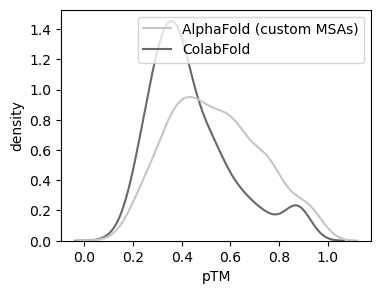

In [34]:
fig, ax = plt.subplots(figsize=(4, 3))

figure_df = alphafold_metadata_df.copy().assign(tool='AlphaFold (custom MSAs)')
figure_df = pd.concat([figure_df, colabfold_metadata_df.loc[alphafold_metadata_df.index].assign(tool='ColabFold')])

# sns.kdeplot(figure_df, x='mean_plddt_best_model', ax=ax, hue='tool', palette='Grays')
sns.kdeplot(figure_df, x='ptm_best_model', ax=ax, hue='tool', palette='Grays')
ax.set_ylabel('density')
ax.set_xlabel('pTM')
ax.get_legend().set_title('')
plt.show()



### Foldseek search

In [ ]:
foldseek_search_query_name = 'genes_prodigal-custom_msa'
foldseek_search_query_dir = f'../data/genes/foldseek/query/{foldseek_search_query_name}'
os.makedirs(foldseek_search_query_dir, exist_ok=True)

# Because Prodigal-predicted sequences already have a minimum length of 30 amino acids, we do not need a length filter here.
print('Number of Foldseek query sequences:', len(os.listdir(alphafold_output_dir)))

Number of Foldseek query sequences: 402


In [19]:
paths = list(glob.glob(os.path.join(alphafold_output_dir, '*')))

for path in tqdm(paths, desc=f'Copying structures to the query directory {foldseek_search_query_dir}.'):
    output = AlphaFoldOutput(path)
    src_path = output.best_model_path
    dst_path = os.path.join(foldseek_search_query_dir, f'{get_gene_id(src_path)}.cif')
    if not os.path.exists(dst_path):
        subprocess.run(f'cp {src_path} {dst_path}', shell=True, check=True)

Copying structures to the query directory ../data/genes/foldseek/query/genes_prodigal-custom_msa.: 100%|██████████| 402/402 [00:02<00:00, 175.12it/s]


In [20]:
# Re-define the query path for the biotite server.
foldseek_search_query_dir = f'/home/philippar/foldseek/query/{foldseek_search_query_name}/'

for target_name, target_path in foldseek_search_target_paths.items():
    foldseek_search_output_path = f'/home/philippar/foldseek/{foldseek_search_query_name}-{target_name}.tsv' # For running on biotite.
    cmd = f'foldseek easy-search {foldseek_search_query_dir} {target_path} {foldseek_search_output_path} tmp -a --alignment-type 1 --format-output "{foldseek_search_fields}"'
    print(f'sbatch --wrap "{cmd}"')

sbatch --wrap "foldseek easy-search /home/philippar/foldseek/query/genes_prodigal-custom_msa/ /shared/db/foldseek/latest/db/pdb /home/philippar/foldseek/genes_prodigal-custom_msa-pdb.tsv tmp -a --alignment-type 1 --format-output "query,target,evalue,gapopen,pident,fident,nident,qstart,qend,qlen,tstart,tend,tlen,alnlen,bits,cigar,qseq,tseq,qheader,theader,qaln,taln,mismatch,qcov,tcov,lddt,lddtfull,qtmscore,ttmscore,alntmscore,rmsd,prob""
sbatch --wrap "foldseek easy-search /home/philippar/foldseek/query/genes_prodigal-custom_msa/ /shared/db/foldseek/latest/db/bfvd /home/philippar/foldseek/genes_prodigal-custom_msa-bfvd.tsv tmp -a --alignment-type 1 --format-output "query,target,evalue,gapopen,pident,fident,nident,qstart,qend,qlen,tstart,tend,tlen,alnlen,bits,cigar,qseq,tseq,qheader,theader,qaln,taln,mismatch,qcov,tcov,lddt,lddtfull,qtmscore,ttmscore,alntmscore,rmsd,prob""
sbatch --wrap "foldseek easy-search /home/philippar/foldseek/query/genes_prodigal-custom_msa/ /shared/db/foldseek/la